# Step 1 : Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

review_df = pd.read_csv(r"D:\Skills Questions\End To End Projects\AI-Based Business Health & Revenue Forecasting Platform\1_Data\Raw Data\Meghana_Reviews_Master_Dataset_222.csv")

review_df.head()

,Review_ID,Rating,Review_Text,Sentiment,Complaint_Category,Churn_Risk
0,R001,1,"Employee misbehaved, order was cancelled, deli...",Negative,Staff Behaviour,High
1,R002,1,Biryani felt overrated and the cost was too hi...,Negative,Pricing,High
2,R003,1,Chicken was found in veg biryani and the resta...,Negative,Food Quality,High
3,R004,1,Paneer biryani was overpriced and the quantity...,Negative,Pricing & Quantity,High
4,R005,1,"Taste has deteriorated, food was oily, service...",Negative,Taste & Service,High


# Basic check

In [2]:
print("Rows:", review_df.shape[0])
print("Columns:", review_df.shape[1])


review_df.info()

Rows: 222
Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Review_ID           222 non-null    object
 1   Rating              222 non-null    int64 
 2   Review_Text         222 non-null    object
 3   Sentiment           222 non-null    object
 4   Complaint_Category  222 non-null    object
 5   Churn_Risk          222 non-null    object
dtypes: int64(1), object(5)
memory usage: 10.5+ KB


# Review KPI Summary

In [3]:
total_reviews = review_df.shape[0]
average_rating = round(review_df["Rating"].mean(), 2)

sentiment_counts = review_df["Sentiment"].value_counts()
positive_pct = round((sentiment_counts.get("Positive", 0) / total_reviews) * 100, 2)
neutral_pct = round((sentiment_counts.get("Neutral", 0) / total_reviews) * 100, 2)
negative_pct = round((sentiment_counts.get("Negative", 0) / total_reviews) * 100, 2)

customer_satisfaction_score = round((average_rating / 5) * 100, 2)

review_kpi = pd.DataFrame({
    "Metric": [
        "Total Reviews Analysed",
        "Average Rating",
        "Positive Reviews %",
        "Neutral Reviews %",
        "Negative Reviews %",
        "Customer Satisfaction Score"
    ],
    "Value": [
        total_reviews,
        average_rating,
        positive_pct,
        neutral_pct,
        negative_pct,
        customer_satisfaction_score
    ]
})

review_kpi

,Metric,Value
0,Total Reviews Analysed,222.00
1,Average Rating,4.10
2,Positive Reviews %,82.43
3,Neutral Reviews %,10.36
4,Negative Reviews %,7.21
5,Customer Satisfaction Score,82.00


# Sentiment distribution

In [4]:
review_df["Sentiment"].value_counts()

Sentiment
Positive    183
Neutral      23
Negative     16
Name: count, dtype: int64

# Sentiment chart

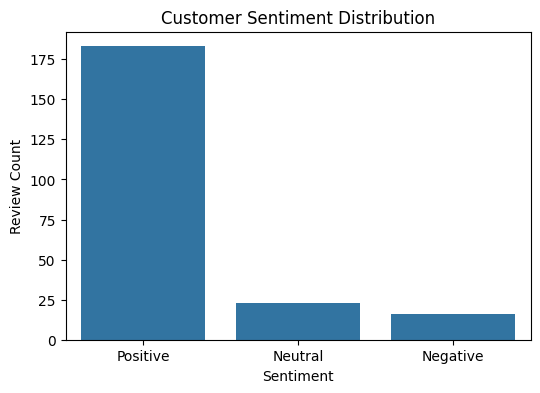

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=review_df,
    x="Sentiment",
    order=review_df["Sentiment"].value_counts().index
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Review Count")
plt.show()

# Rating Distribution Analysis

In [6]:
rating_dist = review_df["Rating"].value_counts().sort_index()

rating_dist

Rating
1    10
2     6
3    23
4    95
5    88
Name: count, dtype: int64

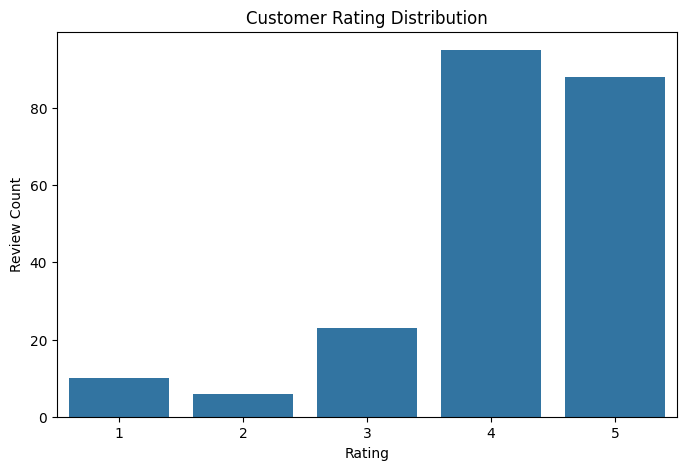

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=review_df,
    x="Rating"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Review Count")

plt.show()

# Complaint Intelligence

In [8]:
complaint_summary = (
    review_df["Complaint_Category"]
    .value_counts()
    .reset_index()
)

complaint_summary.columns = [
    "Complaint_Category",
    "Review_Count"
]

complaint_summary

,Complaint_Category,Review_Count
0,Taste,57
1,Food Quality,32
2,Service,20
3,Value for Money,18
4,Taste & Service,12
5,Crowding,10
6,Portion Size,8
7,Waiting Time,8
8,General Experience,6
9,Taste & Portion Size,5


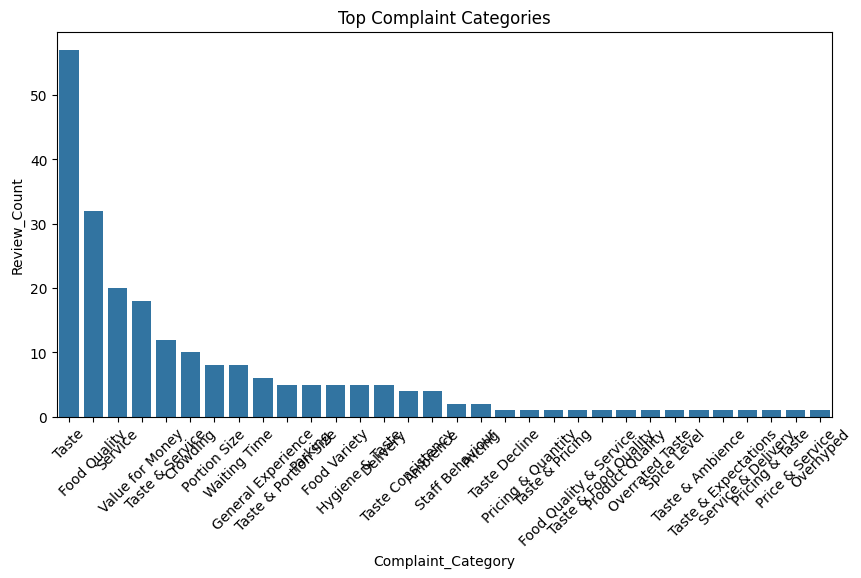

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=complaint_summary,
    x="Complaint_Category",
    y="Review_Count"
)

plt.title("Top Complaint Categories")
plt.xticks(rotation=45)

plt.show()

# create helper functions 

In [10]:
def print_section(title):
    print("\n" + "="*90)
    print(title)
    print("="*90)


def print_subsection(title):
    print("\n" + "-"*90)
    print(title)
    print("-"*90)


def show_actual_reviews(df, rating, n=3):
    reviews = (
        df[df["Rating"] == rating]["Review_Text"]
        .dropna()
        .head(n)
        .tolist()
    )

    for review in reviews:
        print(f'> "{review}"')

# create main report function

In [14]:
def customer_review_intelligence_report(review_df):

    total_reviews = review_df.shape[0]
    avg_rating = round(review_df["Rating"].mean(), 2)

    sentiment_counts = review_df["Sentiment"].value_counts()

    positive_pct = round((sentiment_counts.get("Positive", 0) / total_reviews) * 100, 2)
    neutral_pct = round((sentiment_counts.get("Neutral", 0) / total_reviews) * 100, 2)
    negative_pct = round((sentiment_counts.get("Negative", 0) / total_reviews) * 100, 2)

    satisfaction_score = round((avg_rating / 5) * 100, 2)

    if satisfaction_score >= 80:
        review_health = "Good"
        business_risk = "Medium"
    elif satisfaction_score >= 65:
        review_health = "Moderate"
        business_risk = "Medium to High"
    else:
        review_health = "Needs Immediate Attention"
        business_risk = "High"

    print_section("CUSTOMER REVIEW INTELLIGENCE REPORT")

    print("Review KPI Summary")
    print(f"Total Reviews Analysed: {total_reviews}")
    print(f"Average Rating: {avg_rating} / 5")
    print(f"Positive Reviews: {positive_pct}%")
    print(f"Neutral Reviews: {neutral_pct}%")
    print(f"Negative Reviews: {negative_pct}%")
    print(f"Customer Satisfaction Score: {satisfaction_score} / 100")
    print(f"Overall Review Health: {review_health}")
    print(f"Business Risk Level: {business_risk}")

    # 1. Sentiment Distribution Chart
    print_section("SENTIMENT DISTRIBUTION")

    sentiment_order = ["Positive", "Neutral", "Negative"]

    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=review_df,
        x="Sentiment",
        order=[s for s in sentiment_order if s in review_df["Sentiment"].unique()]
    )
    plt.title("Customer Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Review Count")
    plt.show()

    print("AI Insight:")
    print(
        "The sentiment distribution shows how customers emotionally perceive the restaurant. "
        "A high positive sentiment means customers generally like the brand, but neutral and negative "
        "reviews must still be monitored because they reveal improvement opportunities."
    )

    # 2. Rating Distribution Chart
    print_section("REVIEW DISTRIBUTION BY RATING")

    rating_counts = review_df["Rating"].value_counts().sort_index(ascending=False)

    for rating, count in rating_counts.items():
        print(f"{'⭐'*int(rating)} {count} Reviews")

    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=review_df,
        x="Rating",
        order=sorted(review_df["Rating"].dropna().unique())
    )
    plt.title("Customer Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Review Count")
    plt.show()

    print("AI Insight:")
    print(
        "The rating distribution helps separate customers into business segments. "
        "Five-star customers are brand advocates, four-star customers are easy to convert, "
        "three-star customers are undecided, and one/two-star customers require recovery action."
    )

    # 3. Complaint Category Chart
    print_section("COMPLAINT CATEGORY ANALYSIS")

    complaint_summary = (
        review_df["Complaint_Category"]
        .value_counts()
        .reset_index()
    )

    complaint_summary.columns = [
        "Complaint_Category",
        "Review_Count"
    ]

    display(complaint_summary)

    top_complaints = complaint_summary.head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_complaints,
        x="Review_Count",
        y="Complaint_Category"
    )
    plt.title("Top Customer Complaint Categories")
    plt.xlabel("Review Count")
    plt.ylabel("Complaint Category")
    plt.show()

    print("AI Insight:")
    print(
        "Complaint categories show the real reasons behind customer dissatisfaction. "
        "Instead of only looking at ratings, this helps identify whether the main problem is taste, "
        "food quality, service, pricing, delivery, or overall experience."
    )

    print_section("ACTUAL CUSTOMER VOICE AND STRATEGY BY RATING")

    # 5 Star
    print_subsection("⭐⭐⭐⭐⭐ Brand Advocates")
    print("Actual Customer Reviews:")
    show_actual_reviews(review_df, 5, 3)

    print("\nAI Insight:")
    print(
        "These customers already trust Meghana Foods and are highly satisfied. "
        "They are not just buyers; they can become promoters of the brand. "
        "This group should be rewarded because they can bring referrals, repeat orders, "
        "and positive word-of-mouth marketing."
    )

    print("\nStrategy For 5-Star Customers:")
    print("1. Create a VIP Biryani Club.")
    print("2. After 5 orders, give a free dessert.")
    print("3. After 10 orders, give a free starter.")
    print("4. Start a referral plan: Bring 5 friends and get a free starter.")
    print("5. Give early access to new festival combos or premium dishes.")
    print("\nExpected Impact:")
    print("More referrals, more repeat customers, higher average order value.")

    # 4 Star
    print_subsection("⭐⭐⭐⭐ Growth Segment")
    print("Actual Customer Reviews:")
    show_actual_reviews(review_df, 4, 3)

    print("\nAI Insight:")
    print(
        "These customers are satisfied, but small issues are stopping them from becoming 5-star customers. "
        "They already like the food, so the easiest win is to improve packaging, delivery speed, "
        "service consistency, and small customer delight moments."
    )

    print("\nStrategy For 4-Star Customers:")
    print("1. Improve packaging quality.")
    print("2. Reduce waiting time and delivery delay.")
    print("3. Give a surprise thank-you coupon.")
    print("4. Offer a free dessert coupon on the next order.")
    print("5. Ask for feedback again after improvement.")
    print("\nExpected Impact:")
    print("Higher ratings, more repeat orders, more positive reviews.")

    # 3 Star
    print_subsection("⭐⭐⭐ Opportunity Segment")
    print("Actual Customer Reviews:")
    show_actual_reviews(review_df, 3, 3)

    print("\nAI Insight:")
    print(
        "These customers are undecided. They are not fully unhappy, but they are also not loyal. "
        "This is the highest conversion opportunity because a small improvement in taste, service, "
        "or value can move them from average customers to loyal customers."
    )

    print("\nStrategy For 3-Star Customers:")
    print("1. Launch a recovery campaign.")
    print("2. Give a flat ₹75 coupon on the next order.")
    print("3. Recommend best-selling items instead of letting them randomly reorder.")
    print("4. Ask for feedback again after the next order.")
    print("5. Give a comeback offer valid only for 7 days.")
    print("\nGoal:")
    print("Convert 3-star customers into 4-star and 5-star customers.")

    # 2 Star
    print_subsection("⭐⭐ At-Risk Segment")
    print("Actual Customer Reviews:")
    show_actual_reviews(review_df, 2, 3)

    print("\nAI Insight:")
    print(
        "These customers experienced clear dissatisfaction. In many cases, the issue may not only be food; "
        "it can be taste decline, service delay, spice mismatch, or expectation failure. "
        "This group is at high churn risk and may not return unless recovery action is taken."
    )

    print("\nStrategy For 2-Star Customers:")
    print("1. Send an apology message.")
    print("2. Offer a free dessert or beverage.")
    print("3. Give priority delivery coupon for the next order.")
    print("4. Personally follow up with the customer.")
    print("5. Identify whether the issue was taste, service, spice level, or delay.")
    print("\nExpected Impact:")
    print("Reduced churn, improved retention, and better brand trust.")

    # 1 Star
    print_subsection("⭐ Critical Recovery Segment")
    print("Actual Customer Reviews:")
    show_actual_reviews(review_df, 1, 3)

    print("\nAI Insight:")
    print(
        "These are business-critical reviews. These customers are likely to leave permanently. "
        "Some reviews indicate serious trust-breaking issues such as wrong food, poor service, "
        "delivery delay, pricing dissatisfaction, or staff behaviour problems. "
        "Immediate intervention is required."
    )

    print("\nStrategy For 1-Star Customers:")
    print("1. Manager callback within 24 hours.")
    print("2. Offer a free meal voucher or ₹200 recovery coupon.")
    print("3. Investigate the exact complaint internally.")
    print("4. If the issue is wrong order or food quality failure, treat it as urgent.")
    print("5. Track whether the customer returns after recovery.")
    print("\nExpected Impact:")
    print("Prevent permanent customer loss, protect brand reputation, reduce negative word-of-mouth.")

    print_section("THEME-BASED ROOT CAUSE ANALYSIS")

    print("Top Complaint Themes:")
    display(complaint_summary.head(10))

    food_keywords = [
        "Taste", "Food Quality", "Taste & Service", "Taste Consistency",
        "Taste Decline", "Taste & Food Quality", "Product Quality",
        "Overrated Taste", "Spice Level", "Taste & Ambience",
        "Taste & Expectations", "Hygiene & Taste"
    ]

    service_keywords = [
        "Service", "Waiting Time", "Delivery", "Staff Behaviour",
        "Service & Delivery", "Food Quality & Service", "Price & Service"
    ]

    price_keywords = [
        "Value for Money", "Pricing", "Pricing & Quantity",
        "Taste & Pricing", "Pricing & Taste"
    ]

    food_issue_count = review_df[
        review_df["Complaint_Category"].isin(food_keywords)
    ].shape[0]

    service_issue_count = review_df[
        review_df["Complaint_Category"].isin(service_keywords)
    ].shape[0]

    price_issue_count = review_df[
        review_df["Complaint_Category"].isin(price_keywords)
    ].shape[0]

    print("\nGrouped Root Causes:")
    print(f"Food / Taste Related Issues: {food_issue_count}")
    print(f"Service Related Issues: {service_issue_count}")
    print(f"Pricing Related Issues: {price_issue_count}")

    print("\nAI Root Cause Insight:")
    print(
        "The biggest business risk is not only pricing. "
        "The largest issue is taste and food quality consistency. "
        "Customers visit Meghana Foods mainly for biryani taste. "
        "When taste consistency drops, ratings, loyalty, and repeat orders are affected. "
        "Service and pricing issues are secondary, but they still need correction."
    )

    print_section("SMART FESTIVAL AND CAMPAIGN IDEAS")

    print("1. Pongal Special")
    print("Family Pongal Feast + Free Sweet Pongal")

    print("\n2. Friendship Day")
    print("Friends Biryani Bucket: 6 Friends Combo + 1 Free Dessert")

    print("\n3. Diwali")
    print("Family Celebration Combo + Free Sweet Box")

    print("\n4. Republic Day")
    print("Tri-Colour Special Meal: Limited Edition Campaign")

    print("\n5. Weekend Recovery Offer")
    print("Customers with 1-star, 2-star, and 3-star reviews get comeback coupons.")

    print_section("EXECUTIVE RECOMMENDATION")

    print("Priority 1: Standardize taste across all orders.")
    print("Priority 2: Strengthen food quality controls.")
    print("Priority 3: Improve service consistency.")
    print("Priority 4: Recover at-risk customers.")
    print("Priority 5: Launch loyalty and referral programs.")
    print("Priority 6: Execute festival-based marketing campaigns.")

    print_section("EXPECTED BUSINESS IMPACT")

    print("Expected Benefits:")
    print("• Higher customer satisfaction")
    print("• Better ratings")
    print("• Reduced complaints")
    print("• Higher repeat customers")
    print("• Lower churn risk")
    print("• Higher revenue stability")
    print("• Stronger brand reputation")
    print("• Increased customer lifetime value")





CUSTOMER REVIEW INTELLIGENCE REPORT
Review KPI Summary
Total Reviews Analysed: 222
Average Rating: 4.1 / 5
Positive Reviews: 82.43%
Neutral Reviews: 10.36%
Negative Reviews: 7.21%
Customer Satisfaction Score: 82.0 / 100
Overall Review Health: Good
Business Risk Level: Medium

SENTIMENT DISTRIBUTION


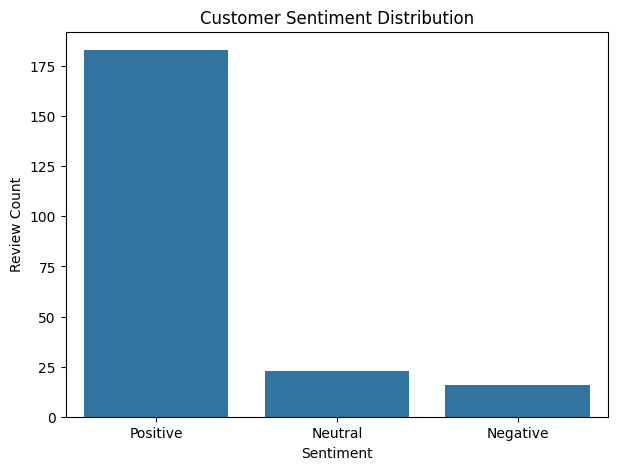

AI Insight:
The sentiment distribution shows how customers emotionally perceive the restaurant. A high positive sentiment means customers generally like the brand, but neutral and negative reviews must still be monitored because they reveal improvement opportunities.

REVIEW DISTRIBUTION BY RATING
⭐⭐⭐⭐⭐ 88 Reviews
⭐⭐⭐⭐ 95 Reviews
⭐⭐⭐ 23 Reviews
⭐⭐ 6 Reviews
⭐ 10 Reviews


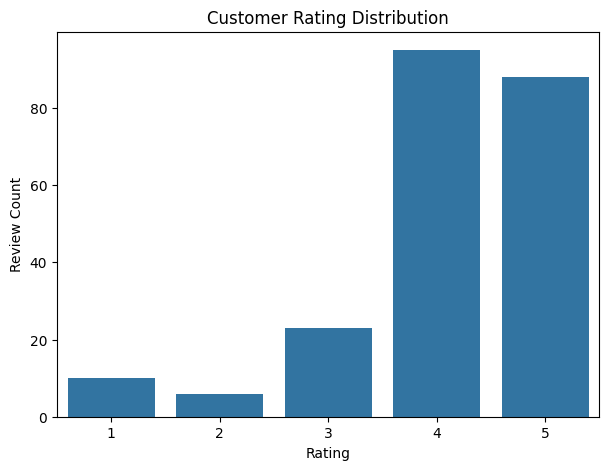

AI Insight:
The rating distribution helps separate customers into business segments. Five-star customers are brand advocates, four-star customers are easy to convert, three-star customers are undecided, and one/two-star customers require recovery action.

COMPLAINT CATEGORY ANALYSIS


,Complaint_Category,Review_Count
0,Taste,57
1,Food Quality,32
2,Service,20
3,Value for Money,18
4,Taste & Service,12
5,Crowding,10
6,Portion Size,8
7,Waiting Time,8
8,General Experience,6
9,Taste & Portion Size,5


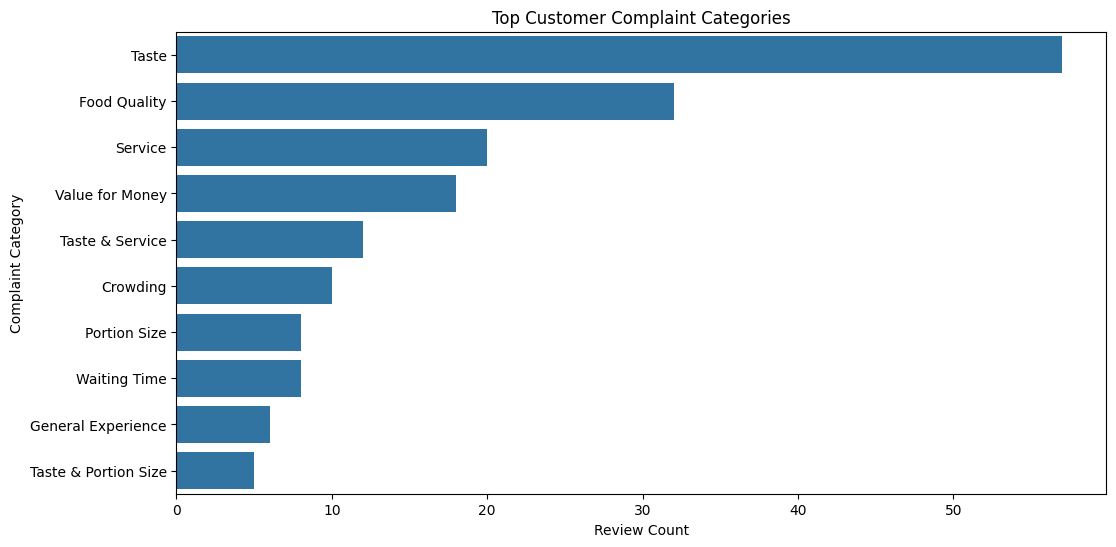

AI Insight:
Complaint categories show the real reasons behind customer dissatisfaction. Instead of only looking at ratings, this helps identify whether the main problem is taste, food quality, service, pricing, delivery, or overall experience.

ACTUAL CUSTOMER VOICE AND STRATEGY BY RATING

------------------------------------------------------------------------------------------
⭐⭐⭐⭐⭐ Brand Advocates
------------------------------------------------------------------------------------------
Actual Customer Reviews:
> "Fantastic authentic Indian food with delicious starters, curry, rice and mango lassi."
> "Amazing biryani with great food and service. Highly recommended."
> "Meghana special biryani was yummy with clean ambience and quick service."

AI Insight:
These customers already trust Meghana Foods and are highly satisfied. They are not just buyers; they can become promoters of the brand. This group should be rewarded because they can bring referrals, repeat orders, and positive wor

,Complaint_Category,Review_Count
0,Taste,57
1,Food Quality,32
2,Service,20
3,Value for Money,18
4,Taste & Service,12
5,Crowding,10
6,Portion Size,8
7,Waiting Time,8
8,General Experience,6
9,Taste & Portion Size,5



Grouped Root Causes:
Food / Taste Related Issues: 117
Service Related Issues: 38
Pricing Related Issues: 23

AI Root Cause Insight:
The biggest business risk is not only pricing. The largest issue is taste and food quality consistency. Customers visit Meghana Foods mainly for biryani taste. When taste consistency drops, ratings, loyalty, and repeat orders are affected. Service and pricing issues are secondary, but they still need correction.

SMART FESTIVAL AND CAMPAIGN IDEAS
1. Pongal Special
Family Pongal Feast + Free Sweet Pongal

2. Friendship Day
Friends Biryani Bucket: 6 Friends Combo + 1 Free Dessert

3. Diwali
Family Celebration Combo + Free Sweet Box

4. Republic Day
Tri-Colour Special Meal: Limited Edition Campaign

5. Weekend Recovery Offer
Customers with 1-star, 2-star, and 3-star reviews get comeback coupons.

EXECUTIVE RECOMMENDATION
Priority 1: Standardize taste across all orders.
Priority 2: Strengthen food quality controls.
Priority 3: Improve service consistency.
Pri

In [15]:
customer_review_intelligence_report(review_df)